# [1.3.1] Linear probes ① — probe는 무엇을 묻는가

**한국어 재구성판 · Llama-3.1-8B-Instruct · transformers 5 · PyTorch block hook (2026-10)**

이 장은 ARENA [1.3.1] Linear Probes를 다시 쓴 것이다. 원본은 *Geometry of Truth*를 재현하는 순서(activation → PCA → probe → 개입 → deception)로 진행한다. 이 판은 같은 재료를 **두 번** 지나간다.

1. **1부 — 주장 세우기 (①~⑤).** 논문을 쓰는 사람의 순서다. 관찰 하나를 얻고, 그 관찰을 다르게 설명할 대안을 실험으로 하나씩 약화시키고, 일반화와 인과 증거를 쌓은 뒤 ⑤에서 초록을 쓴다.
2. **2부 — 주장 허물기 (⑥~⑧).** 심사위원의 순서다. 부정문, "읽힘 ≠ 쓰임", 감시 도구로서의 실패 모드, 2024–2026년 연구로 1부의 주장을 다시 시험하고, 살아남은 범위만 남긴다.

> 핵심 위치: linear probe의 성공은 **"이 모델·이 층·이 위치·이 데이터에서 label이 선형으로 읽힌다"** 는 관찰이다.
> 이것이 "모델이 진실이라는 개념을 가진다", "모델이 그것을 계산에 쓴다", "거짓말 탐지기로 쓸 수 있다"로 올라가려면
> 단계마다 **다른 종류의 증거**가 필요하다. 이 장 전체가 그 사다리를 올랐다가 다시 내려오는 연습이다.

## 이 장의 구조

| notebook | 부 | 이 notebook이 묻는 것 |
|---|---|---|
| **① probe는 무엇을 묻는가 (지금)** | 1부 | probe는 정확히 무엇을 묻는가? 왜 선형인가? 실제 모델에서 무엇이 보이는가? |
| ② 성공을 증거로 만들기 | 1부 | 높은 점수를 만드는 다른 설명(표면 통계, probe 용량, 문장 확률)을 배제할 수 있는가? |
| ③ 일반화 | 1부 | 도시 문장으로 배운 방향이 다른 주제·형식·언어에서도 통하는가? |
| ④ 인과 개입 | 1부 | 그 방향으로 activation을 밀면 모델의 판단이 바뀌는가? 무작위 방향과 구별되는가? |
| ⑤ 논문 초안 | 1부 → 2부 | 지금까지의 증거로 어디까지 주장할 수 있는가? 초록을 쓴다. |
| ⑥ 반박 1 — 부정문과 극성 | 2부 | "보편적 truth 방향"은 부정문에서도 살아남는가? |
| ⑦ 반박 2 — 읽힘과 쓰임 | 2부 | 읽힌다·지우면 망가진다·밀면 바뀐다는 각각 무엇을 증명하는가? |
| ⑧ 반박 3 — 감시 도구로서의 probe, 최종 판정 | 2부 | 실제 monitor로 쓰면 무엇이 깨지는가? 최종적으로 어떤 주장이 남는가? |

원본 ARENA와의 관계: 원본의 §1–3(truth probe, PCA, 개입)은 ①~④에, §4(deception probe)는 ⑧에 들어 있다. 원본 §5(attention probe)는 ⑧에서 문헌으로만 다룬다. 모델은 원본의 Llama-2-13B 대신 **Llama-3.1-8B-Instruct 하나**로 통일했다. 2024–2026 후속 연구(Bürger et al., Apollo, GDM·Anthropic의 운영 probe, 회피 공격 등)가 주로 이 세대 모델을 쓰기 때문이다.

## 학습 목표, 필수 경로, stop rule

이 notebook의 필수 경로는 네 단계다.

1. probe 실험이 **직접** 답하는 질문을 한 문장으로 쓴다.
2. "왜 하필 선형인가"에 대한 세 가지 논증과 각각의 약점을 구분한다.
3. mass-mean(MM) probe와 logistic regression(LR) probe가 기하학적으로 무엇이 다른지 toy 데이터로 확인한다.
4. block hook으로 activation을 뽑고, 누수 없는 split에서 층 sweep을 해 **첫 관찰**을 얻는다.

### ②로 넘어가도 되는 기준

아래를 자신의 말로 설명할 수 있으면 ①은 완료다.

- "test AUROC 1.0"이라는 결과만으로는 **아직 말할 수 없는 것** 세 가지
- MM probe에서 bias(두 평균의 중점)를 빼먹으면 왜 다른 분류기가 되는가
- 층을 test 성능으로 고르면 안 되는 이유, 그리고 validation AUROC가 1.0으로 포화되었을 때 무엇으로 고르는가

toy의 분포 이동 실험, PCA 그림의 세부 해석은 **선택**이다. 남겨 두어도 ②로 넘어가는 데 지장이 없다.

## 2026년 관점

2026년의 linear probe는 **연구 도구이면서 동시에 운영 중인 안전 장치**다.

- Anthropic은 모든 트래픽을 값싼 activation probe로 먼저 거르고 의심스러운 대화만 비싼 분류기로 넘기는 구조를 공개했다(Constitutional Classifiers++, [arXiv:2601.04603](https://arxiv.org/abs/2601.04603), 2026-01).
- Google DeepMind는 Gemini의 사이버 악용 탐지에 probe를 배치하면서, 짧은 문맥에서 학습한 probe가 긴 문맥에서 깨지는 문제를 보고했다([arXiv:2601.11516](https://arxiv.org/abs/2601.11516), 2026-01).

동시에 같은 해의 연구들은 이 도구로 할 수 있는 **주장의 상한**을 낮추고 있다.

- 믿음이 검증된 model organism에서는 activation 기반 거짓말 탐지기의 성능이 "급락"했고, 저자들은 현재 탐지기로 모델의 믿음에 대한 확신 있는 주장을 할 수 없다고 결론냈다(Cooney, Africa & Irving, [arXiv:2606.12618](https://arxiv.org/abs/2606.12618), 2026-06).
- 기존 lie-detection probe 8개가 진실 대신 "지시 준수"나 "응답의 그럴듯함"을 따라간다는 stress test가 나왔다(von Klinski et al., [arXiv:2609.39807](https://arxiv.org/abs/2609.39807), 2026-09).
- monitor의 판정만 피드백으로 받아도 모델이 activation을 바꿔 감시를 피하는 법을 배운다는 결과가 나왔다(Keenan et al., [arXiv:2609.36490](https://arxiv.org/abs/2609.36490), 2026-09).

그래서 이 장의 질문은 "probe가 좋은가 나쁜가"가 아니다. **어떤 주장을, 어떤 증거로, 어느 강도까지 할 수 있는가**다.

## 주장 장부 (claim ledger)

각 notebook은 끝에서 **주장 장부**를 갱신한다. 표의 열은 항상 같다.

| ID | 주장 | 근거(이 장에서 실행한 실험) | 아직 배제하지 못한 설명 | 상태 |
|---|---|---|---|---|

상태는 `관찰됨` → `지지됨` → (2부에서) `유지` / `범위 축소` / `기각` 중 하나로 바뀐다. 1부에서는 장부의 항목을 **늘리고 강하게** 만들고, 2부에서는 같은 장부를 **다시 깎는다**. ⑤와 ⑧은 이 장부를 모아서 읽는다(`results/*.json`).

## 실행 환경과 메모리 원칙

- **GPU:** bf16 8B 모델(약 16 GiB) + activation. 24 GiB 이상 권장. RTX A6000(48 GiB)에서 전체를 실행해 출력을 저장했다.
- **모델:** `meta-llama/Llama-3.1-8B-Instruct`는 gated model이다. Hugging Face에서 접근 승인을 받은 계정으로 `hf auth login`을 한 번 해 둔다. 토큰을 notebook이나 저장소 파일에 쓰지 않는다.
- **cache:** activation은 `cache/`에 float16으로 저장된다(git 제외). 한 번 계산하면 다시 실행할 때 forward가 필요 없다.
- **메모리 원칙:** 모델은 한 번에 하나만 올린다. 전체 activation cache 대신 **필요한 층의 필요한 위치(마지막 token)만** hook으로 모은다. 반복 forward는 `torch.inference_mode()` 아래에서 한다.
- **다른 모델:** `pl.DEFAULT_MODEL`을 바꾸면 코드는 Llama/Qwen 계열에서 그대로 돈다. 그러나 이 교재의 숫자와 층 번호는 Llama-3.1-8B-Instruct의 저장된 출력이다. 모델을 바꾸면 층 선택부터 다시 해야 한다(다른 모델은 검증하지 않았다).

## 공통 setup — import는 이 셀 한 곳에서만

#### Cell 01 · 실행 환경과 공통 import

- **이번 셀의 질문:** 뒤의 hook·probe 코드가 가정하는 환경을 현재 kernel이 만족하는가?
- **출력에서 볼 것:** 출력된 torch·transformers 버전과 GPU 이름을 본다. 저장된 출력은 torch 2.11, transformers 5.18, RTX A6000이다.
- **해석 범위:** 환경 확인일 뿐이다. 모델은 아직 불러오지 않았다. `probe_lab.py`는 이 장의 reference 구현과 실험 도구, `tests.py`는 exercise 확인용이다.
- **다음 단계의 목적:** probe 실험이 무엇을 묻는지 먼저 정의한 뒤 모델을 불러온다.

In [1]:
# 공통 setup — import는 이 셀 한 곳에서만 한다.
from __future__ import annotations

import gc
import sys
from importlib.metadata import version
from pathlib import Path

HERE = Path.cwd()
if not (HERE / "probe_lab.py").exists():  # 저장소 root 등 다른 위치에서 연 경우
    HERE = next(
        p
        for p in [HERE / "chapter1_transformer_interp/exercises/part31_linear_probes_ko", *HERE.parents]
        if (p / "probe_lab.py").exists()
    )
sys.path.insert(0, str(HERE))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

import probe_lab as pl
import tests

pl.use_style()
np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.precision", 3)
pd.set_option("display.width", 140)

print({
    "torch": torch.__version__,
    "transformers": version("transformers"),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "model": pl.DEFAULT_MODEL,
})

{'torch': '2.11.0+cu128', 'transformers': '5.18.0', 'gpu': 'NVIDIA RTX A6000', 'model': 'meta-llama/Llama-3.1-8B-Instruct'}


# 1️⃣ probe 실험이 직접 답하는 질문

모델 $M$을 **고정**한다. 데이터 분포 $\mathcal D$에서 문장 $x$와 label $y \in \{0,1\}$을 뽑는다. layer $\ell$, token 위치 $p$의 activation을 $h = h_{\ell,p}(x) \in \mathbb R^d$라 하자. linear probe는

$$f_{w,b}(h) = \sigma(w^\top h + b)$$

이고, $(w,b)$는 train 문장들로만 학습한다. 모델의 weight는 한 번도 바뀌지 않는다.

**probe 실험이 직접 답하는 질문은 하나다.**

> "학습에 쓰지 않은 문장에서 $y$를 우연보다 잘 맞히는 선형 함수 $f_{w,b}$가 존재하는가?"

이 질문에 "그렇다"가 나와도, 아래는 **직접 답해지지 않는다.**

1. 모델이 $y$라는 **개념**을 가지고 있는가? (probe가 여러 특징을 조합해 $y$를 만들어 냈을 수 있다)
2. 모델이 $h$에 있는 $y$ 정보를 **사용**하는가? (읽히지만 아무도 읽지 않는 정보일 수 있다)
3. $\mathcal D$ 밖의 분포에서도 같은 $f$가 통하는가? (train 분포의 우연한 상관을 읽었을 수 있다)

1부의 나머지는 1·2·3에 대한 **간접 증거**를 쌓는 과정이다.

## 왜 하필 선형인가 — 저자가 쓰는 세 가지 논증

비선형 probe(MLP)를 쓰면 정확도는 거의 항상 같거나 더 높다. 그런데도 논문들이 선형 probe를 고집하는 이유는 세 가지 논증 때문이다. 각 논증에는 이미 알려진 약점이 있다.

| 논증 | 내용 | 약점 |
|---|---|---|
| **용량 제한** | 선형 probe는 스스로 복잡한 계산을 할 수 없다. 그러니 성공했다면 정보가 이미 "쉽게 꺼낼 수 있는 형태"로 있었다는 뜻이다. ([Alain & Bengio 2016](https://arxiv.org/abs/1610.01644); probe 자체의 암기 능력을 재는 *control task*와 *selectivity*: [Hewitt & Liang 2019](https://arxiv.org/abs/1909.03368)) | 고차원에서는 선형 probe도 충분히 강하다. 표본 수 $n$이 차원 $d$보다 작으면 거의 어떤 label이든 train에서 분리된다. 정보이론 관점에서는 "가장 좋은 probe를 써야 한다"는 반대 주장도 있다([Pimentel et al. 2020](https://arxiv.org/abs/2004.03061)). → ②, ⑦ |
| **하류 접근성** | Transformer의 다음 구성요소들은 residual stream을 (정규화 후) **선형 사상**으로 읽는다: $W_Q, W_K, W_V$, MLP의 $W_{in}$, 최종 $W_U$. 선형으로 읽히는 정보는 뒤의 어느 component에게나 "행렬곱 한 번" 거리에 있다. | "쓸 수 있다"와 "쓴다"는 다르다. 모델이 쓰지 않는 성질도 선형으로 읽힌다([Ravichander et al. 2021](https://arxiv.org/abs/2005.00719)). → ④, ⑦ |
| **선형 표현 가설** | 개념이 activation 공간의 **방향**으로 표현된다면([Park, Choe & Veitch 2023](https://arxiv.org/abs/2311.03658)), probe가 찾은 방향으로 activation을 더하고 빼서 **인과 실험**을 할 수 있다. | 모든 특징이 1차원 방향은 아니다. 요일·월은 원(circle) 위에 놓인다([Engels et al. 2024](https://arxiv.org/abs/2405.14860)). 크기로 정보를 담는 "onion" 표현도 있다([Csordás et al. 2024](https://arxiv.org/abs/2408.10920)). → ⑦ |

세 논증은 서로를 보완한다. **용량 제한**은 "정보가 거기 있다"를, **하류 접근성**은 "모델이 쓸 수 있는 형태다"를, **선형 표현 가설**은 "그렇다면 개입으로 확인할 수 있다"를 지지한다. 1부는 이 세 논증을 실험으로 하나씩 받쳐 주고, 2부는 약점 열을 실험으로 찌른다.

## 높은 점수를 만드는 다른 설명들

probe가 성공했을 때 "진실이 표현되어 있다" 말고도 같은 숫자를 만드는 설명이 여럿 있다. 1부의 각 notebook은 이 표의 한두 줄을 맡는다. 이 표가 이 장의 **목차**다.

| 기호 | 대안 설명 | 높은 AUROC를 이렇게도 만들 수 있다 | 약화시키는 실험 | 위치 |
|---|---|---|---|---|
| A1 | 누수 | 같은 도시가 train/test 양쪽에 있다 | 도시 단위 group split | ① |
| A2 | 선택 편향 | test 성능을 보고 층·초매개변수를 골랐다 | validation으로 미리 고정, test는 한 번 | ① |
| A3 | 표면 통계 | 국가 이름의 prior나 단어 분포만으로 맞힌다 | country one-hot, bag-of-words baseline | ② |
| A4 | probe 용량 | 고차원에서 아무 label이나 외운다 | label을 섞은 귀무분포, random-init 모델 | ② |
| A5 | 확률·그럴듯함 | "참"이 아니라 "자주 보던 문장"을 표시한다 | 문장 log-prob 비교, (2부) 부정문 | ②, ⑥ |
| A6 | 데이터셋 특수성 | 도시–국가 연관만 읽는다 | 다른 주제·형식으로 일반화 | ③, ⑥ |
| A7 | 부수현상 | 읽히지만 모델이 쓰지 않는다 | 개입(steering), 제거(erasure) | ④, ⑦ |

#### Cell 02 · Scratch: 결과를 보기 전에 예측하기

- **이번 셀의 질문:** cities 문장에서 layer 0과 layer 12의 probe AUROC는 각각 얼마일까? 어떤 층부터 분리될까?
- **출력에서 볼 것:** 빈 셀이다. 예측과 그 이유를 주석으로 적는다. 아래에서 실제 층 sweep을 본 뒤 이 셀로 돌아와 비교한다.
- **해석 범위:** 예측 자체는 증거가 아니다. 다만 결과를 본 뒤 이야기를 맞추는 일을 막아 준다.
- **다음 단계의 목적:** probe의 두 종류(MM, LR)가 무엇을 계산하는지 toy 데이터로 먼저 확인한다.

In [2]:
# 예측 (실행 결과 없음):
#   layer 0 AUROC ≈ ?   이유:
#   layer 12 AUROC ≈ ?  이유:
#   처음으로 0.9를 넘는 층 ≈ ?

# 2️⃣ 작동 원리 — MM과 LR은 무엇이 다른가

이 장에서는 두 종류의 linear probe를 쓴다.

**Mass-mean(MM) probe** ([Marks & Tegmark 2023](https://arxiv.org/abs/2310.06824))

$$\theta_{mm} = \mu_1 - \mu_0, \qquad \text{score}(x) = \theta_{mm}^\top\Big(x - \tfrac{\mu_1+\mu_0}{2}\Big)$$

두 class 평균의 차이 방향으로 투영하고, 두 평균의 **중점**에서 자른다. 학습이라고 부를 것도 없이 평균 두 개만 계산한다.

**Logistic regression(LR) probe**

$$\min_{w,b}\; \tfrac12\|w\|^2 + C\sum_i \text{log-loss}\big(w^\top x_i + b,\; y_i\big)$$

조건부 우도를 최대화한다. 두 class가 공분산 $\Sigma$를 공유하는 Gaussian이면 최적 판별 방향은 $\Sigma^{-1}(\mu_1-\mu_0)$이고(LDA), LR은 이것에 가까워진다. 즉 **LR은 class 내부 잡음이 큰 방향을 피하도록 방향을 기울인다.** MM은 공분산을 보지 않는다.

정리하면 두 probe는 다른 질문에 답한다.

- MM: "두 class의 평균이 **어느 방향으로** 다른가?"
- LR: "어느 방향으로 투영해야 두 class가 **가장 잘 구분되는가?**"

공분산이 등방적이면 두 방향은 같다. 아니면 다르고, 그 차이가 ③(일반화)과 ④(개입)에서 실제로 결과를 가른다.

### ✏️ Exercise 1 · `fit_mass_mean`, `fit_logistic` 구현

> 난이도 🔴🔴⚪⚪⚪ · 중요도 🔵🔵🔵🔵⚪ · 15~20분

두 함수 모두 `pl.LinearProbe(direction, bias, kind)`를 돌려준다. `score(X) = X @ direction + bias`이고, **direction과 bias는 원래 activation 좌표**여야 한다.

- `fit_mass_mean(X, y)`: 위 식 그대로. bias를 빼먹지 않는다.
- `fit_logistic(X, y, C)`: 표준화 좌표 $z = (x-m)/s$에서 학습해도 된다(sklearn `LogisticRegression` 사용 가능). 다만 반환할 때 raw 좌표로 되돌린다: $w_{raw} = w_z / s$, $b_{raw} = b_z - w_{raw}^\top m$.

왜 raw 좌표가 중요한가? 표준화 좌표의 $w_z$를 residual stream에 그대로 더하면 **다른 방향을 조작**하게 된다. 방향끼리 cosine을 비교할 때도 마찬가지다. 원본 ARENA 코드에서 이 부분이 섞여 있었다.

먼저 아래 scratch 셀에서 직접 구현하고 `MY_IMPL = True`로 바꿔 테스트한다. 그다음 reference 셀과 비교한다.

In [3]:
# Scratch — 직접 구현한 뒤 MY_IMPL = True 로 바꾸고 실행한다.
MY_IMPL = False

def my_fit_mass_mean(X: np.ndarray, y: np.ndarray) -> pl.LinearProbe:
    """X: [N, D], y: [N] ∈ {0,1} → LinearProbe (raw 좌표)."""
    raise NotImplementedError

def my_fit_logistic(X: np.ndarray, y: np.ndarray, C: float = 0.1) -> pl.LinearProbe:
    """표준화 좌표에서 학습하고 raw 좌표로 되돌린다."""
    raise NotImplementedError

if MY_IMPL:
    tests.test_fit_mass_mean(my_fit_mass_mean)
    tests.test_fit_logistic(my_fit_logistic)

#### Cell 03 · Reference 구현: MM probe와 LR probe

- **이번 셀의 질문:** 두 probe를 raw 좌표로 정확히 구현했는가?
- **출력에서 볼 것:** 두 테스트가 모두 ✅를 출력하는지 본다. LR의 raw 좌표 방향이 reference와 cos≈1.0이어야 한다.
- **해석 범위:** 아래 `fit_logistic_reference`는 sklearn으로 쓴 읽기용 구현이다. `probe_lab.fit_logistic`은 같은 목적함수를 torch L-BFGS로 푼다(4096차원에서 sklearn CPU 풀이는 수 분이 걸린다). 두 구현의 해가 같다는 것을 이 셀이 확인한다.
- **다음 단계의 목적:** 두 방향이 실제로 어떻게 다른지 2차원 toy 데이터에서 그림으로 본다.

In [4]:
from sklearn.linear_model import LogisticRegression


def fit_mass_mean_reference(X: np.ndarray, y: np.ndarray) -> pl.LinearProbe:
    """θ = μ₁ − μ₀, bias = −θ·(μ₁+μ₀)/2. X: [N, D], y: [N]."""
    mu1, mu0 = X[y == 1].mean(0), X[y == 0].mean(0)
    theta = mu1 - mu0
    return pl.LinearProbe(theta, float(-theta @ (mu1 + mu0) / 2), "MM")


def fit_logistic_reference(X: np.ndarray, y: np.ndarray, C: float = 0.1) -> pl.LinearProbe:
    """표준화 좌표에서 sklearn LR을 학습하고 raw 좌표 (w_raw, b_raw)로 되돌린다."""
    m, s = X.mean(0), X.std(0) + 1e-6
    clf = LogisticRegression(C=C, max_iter=10_000, tol=1e-8).fit((X - m) / s, y)
    w_raw = clf.coef_[0] / s
    b_raw = float(clf.intercept_[0] - w_raw @ m)
    return pl.LinearProbe(w_raw, b_raw, "LR")


tests.test_fit_mass_mean(fit_mass_mean_reference)
tests.test_fit_logistic(fit_logistic_reference)

✅ fit_mass_mean: 방향·중점 bias·평행 이동 불변성 통과


✅ fit_logistic: raw 좌표 방향 cos=1.0000, score 상관 1.0000


#### Cell 04 · Toy: MM 방향과 LR 방향이 갈라지는 경우

- **이번 셀의 질문:** class 내부 잡음이 두 축에 걸쳐 강하게 상관되어 있으면 두 probe의 방향은 어떻게 달라지는가?
- **출력에서 볼 것:** 왼쪽 그림에서 회색 화살표(MM)는 두 평균의 차이 방향(x₁ 축), 청록 화살표(LR)는 잡음이 큰 대각선 방향을 피하도록 기울어진 방향이다. 표에서 같은 분포(in-dist)의 정확도는 LR이 높다.
- **해석 범위:** 이 데이터는 일부러 만든 2차원 예시다. LLM에서 같은 일이 일어난다는 증거가 아니라, 두 probe가 **다른 질문**에 답한다는 것을 보이는 장치다.
- **다음 단계의 목적:** 잡음의 상관 구조만 뒤집은 분포에서 두 probe가 어떻게 되는지 본다.

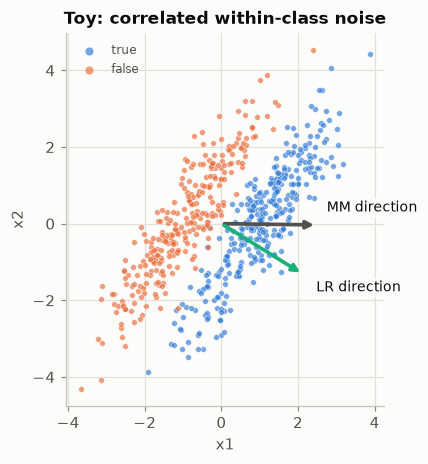

,probe,direction (unit),acc in-dist,acc shifted noise
0,MM,"[1.0, -0.013]",0.838,0.833
1,LR,"[0.85, -0.527]",0.992,0.695


cos(MM, LR) = 0.857


In [5]:
rng = np.random.default_rng(0)


def make_toy(n: int, rho_sign: float, rng) -> tuple[np.ndarray, np.ndarray]:
    """class 평균 차이는 x₁ 축(±1), class 내부 잡음은 두 축이 상관(corr = 0.9·rho_sign)."""
    y = rng.integers(0, 2, n)
    tau = 2 * y - 1
    cov = np.array([[1.0, 1.35 * rho_sign], [1.35 * rho_sign, 2.25]])
    X = np.c_[tau * 1.0, np.zeros(n)] + rng.multivariate_normal([0, 0], cov, size=n)
    return X, y


X_toy, y_toy = make_toy(2000, +1, rng)
X_shift, y_shift = make_toy(2000, -1, rng)   # 잡음의 상관 부호만 뒤집은 분포
mm_toy = pl.fit_mass_mean(X_toy, y_toy)
lr_toy = pl.fit_logistic(X_toy, y_toy, C=10.0)

fig, ax = plt.subplots(figsize=(5.2, 4.4))
pl.scatter_classes(ax, X_toy[:600], y_toy[:600], title="Toy: correlated within-class noise", xlabel="x1", ylabel="x2")
for probe, color, name, offset in [(mm_toy, pl.INK2, "MM", (0.25, 0.35)), (lr_toy, pl.C_THIRD, "LR", (0.35, -0.45))]:
    u = probe.unit * 2.5
    ax.annotate("", xy=u, xytext=(0, 0), arrowprops=dict(arrowstyle="-|>", lw=2.4, color=color))
    ax.text(u[0] + offset[0], u[1] + offset[1], f"{name} direction", color=pl.INK, fontsize=9, ha="left",
            bbox=dict(boxstyle="round,pad=0.2", fc=pl.SURFACE, ec="none", alpha=0.85))
ax.set_aspect("equal")
plt.show()

rows = []
for name, probe in [("MM", mm_toy), ("LR", lr_toy)]:
    rows.append({
        "probe": name,
        "direction (unit)": np.round(probe.unit, 3),
        "acc in-dist": pl.accuracy(y_toy, probe.score(X_toy)),
        "acc shifted noise": pl.accuracy(y_shift, probe.score(X_shift)),
    })
display(pd.DataFrame(rows))
print("cos(MM, LR) =", round(pl.cosine(mm_toy.direction, lr_toy.direction), 3))

### 해석 checkpoint — toy가 보여 준 것

- 같은 분포에서는 LR이 더 정확하다(저장된 출력: LR 약 0.99, MM 약 0.84). LR은 $x_2$에 실린 상관된 잡음을 이용해 $x_1$의 잡음을 상쇄한다.
- 잡음의 상관 구조만 뒤집으면 LR은 크게 떨어지고(약 0.70) MM은 그대로다(약 0.83). LR이 이용한 것은 **class 차이가 아니라 train 분포의 잡음 구조**였기 때문이다.
- 그러니 "LR이 더 정확하다"와 "LR 방향이 모델의 진실 변수다"는 다른 주장이다. Marks & Tegmark도 분류에는 $\Sigma^{-1}\theta_{mm}$(LDA형)을, 개입에는 $\theta_{mm}$을 쓰라고 제안했다. 실제 모델에서 이 차이는 ③(일반화)과 ④(개입)에서 다시 나온다.

**AUROC와 accuracy.** AUROC는 score의 **순위**만 본다(threshold 무관). accuracy는 score > 0이라는 **threshold**에 의존한다. MM의 bias를 빼먹으면 AUROC는 그대로인데 accuracy만 망가진다. 이 장에서는 두 지표를 항상 함께 본다.

# 3️⃣ 실제 모델에서 activation 뽑기

이제 Llama-3.1-8B-Instruct에 *Geometry of Truth*의 `cities` 문장을 넣는다.

> `The city of Krasnodar is in Russia.` (참) / `The city of Krasnodar is in Japan.` (거짓)

**어디를 읽는가.** decoder block $\ell$의 출력(= TransformerLens의 `blocks.ℓ.hook_resid_post`)에서, 문장의 **마지막 token(마침표)** 을 읽는다. 마침표 같은 문장 끝 token에 앞 내용이 "요약"된다는 관찰이 여러 번 보고되었다(Marks & Tegmark; 감정 방향의 요약 위치: [Tigges et al. 2023](https://arxiv.org/abs/2310.15154)).

**왜 hook인가.** HF의 `output_hidden_states=True`는 모든 층·모든 위치를 저장하므로 메모리를 많이 쓴다. 게다가 마지막 원소는 final norm을 거친 값이라 block 31의 출력과 다르다(transformers 5.18에서 확인). 필요한 위치만 hook으로 모으면 둘 다 피한다.

### ✏️ Exercise 2 · `extract_last_token` 구현

> 난이도 🔴🔴🔴⚪⚪ · 중요도 🔵🔵🔵🔵🔵 · 20~30분

`texts` 각각의 **마지막 유효 token**에서 지정한 층들의 block 출력을 모은다.

- 길이가 다른 문장을 한 batch에 넣으면 padding이 생긴다. tokenizer는 right padding으로 설정되어 있다. 각 행의 마지막 유효 위치는 `attention_mask.sum(1) - 1`이다.
- `model.model.layers[l].register_forward_hook(hook)`로 붙인다. transformers 5.x의 Llama block은 Tensor를, 4.x 일부는 `(Tensor, ...)` tuple을 반환한다. 둘 다 처리한다.
- hook은 `try/finally`로 반드시 제거한다.
- `lm_head`(vocab 128k)는 필요 없으므로 `model.model(...)`만 실행한다.
- 반환: `{layer: [N, D] float32 CPU tensor}`

In [6]:
# Scratch — 직접 구현한 뒤 MY_IMPL = True 로 바꾼다. (모델을 불러온 다음 셀 이후에 테스트가 돈다)
MY_IMPL = False

@torch.inference_mode()
def my_extract_last_token(model, tokenizer, texts, layers, batch_size: int = 32) -> dict[int, torch.Tensor]:
    raise NotImplementedError

#### Cell 05 · 모델 불러오기

- **이번 셀의 질문:** bf16 8B 모델이 GPU에 올라가고, decoder block이 몇 개인가?
- **출력에서 볼 것:** `layers=32`, `d_model=4096`, `dtype=torch.bfloat16`과 GPU 사용량(약 15 GiB)을 본다.
- **해석 범위:** `ActivationStore`는 계산한 activation을 `cache/`에 저장하는 얇은 래퍼다. 같은 데이터셋·층을 다시 요청하면 forward 없이 disk에서 읽는다.
- **다음 단계의 목적:** Exercise 2의 reference 구현을 실행하고, 내 구현이 있으면 비교한다.

In [7]:
model, tok = pl.load_model(pl.DEFAULT_MODEL)
store = pl.ActivationStore(model=model, tokenizer=tok)
N_LAYERS = len(pl.decoder_layers(model))
print({"layers": N_LAYERS, "d_model": model.config.hidden_size,
       "dtype": str(next(model.parameters()).dtype),
       "GPU GiB": round(torch.cuda.memory_allocated() / 2**30, 1) if torch.cuda.is_available() else None})

{'layers': 32, 'd_model': 4096, 'dtype': 'torch.bfloat16', 'GPU GiB': 15.0}


#### Cell 06 · Reference 구현과 테스트: 마지막 token의 block 출력

- **이번 셀의 질문:** 길이가 다른 문장이 섞여도 각 문장의 진짜 마지막 token을 읽는가?
- **출력에서 볼 것:** `✅ extract_activations ...`가 출력되는지 본다. 테스트는 길이가 크게 다른 문장 4개를 한 batch로 넣는다.
- **해석 범위:** `probe_lab.extract_activations`는 이 함수에 '평균 구간(char span)' 옵션을 더한 것이다. 이후 notebook은 그것을 쓴다.
- **다음 단계의 목적:** cities 데이터를 불러오고, 도시 단위로 split한다.

In [8]:
@torch.inference_mode()
def extract_last_token(model, tokenizer, texts, layers, batch_size: int = 32) -> dict[int, torch.Tensor]:
    """texts 각각의 마지막 유효 token에서 decoder block 출력(resid_post)을 모은다.

    Returns: {layer: [N, D] float32 CPU tensor}
    """
    blocks = model.model.layers
    device = next(model.parameters()).device
    collected: dict[int, list[torch.Tensor]] = {l: [] for l in layers}
    state: dict[str, torch.Tensor] = {}

    def make_hook(layer: int):
        def hook(module, inputs, output):
            h = output[0] if isinstance(output, tuple) else output      # [B, S, D]
            b = torch.arange(h.shape[0], device=h.device)
            collected[layer].append(h[b, state["last"]].float().cpu())  # [B, D]
        return hook

    handles = [blocks[l].register_forward_hook(make_hook(l)) for l in layers]
    try:
        for s in range(0, len(texts), batch_size):
            enc = tokenizer(list(texts[s : s + batch_size]), return_tensors="pt", padding=True).to(device)
            state["last"] = enc["attention_mask"].sum(1) - 1   # right padding → 마지막 유효 위치
            model.model(input_ids=enc["input_ids"], attention_mask=enc["attention_mask"])
    finally:
        for h in handles:
            h.remove()
    return {l: torch.cat(v) for l, v in collected.items()}


tests.test_extract_activations(extract_last_token, model, tok)
if MY_IMPL:
    tests.test_extract_activations(my_extract_last_token, model, tok)

✅ extract_activations: 길이가 다른 문장 4개, layer 0·12에서 reference와 일치


#### Cell 07 · cities 데이터와 도시 단위 split (A1 누수 차단)

- **이번 셀의 질문:** 같은 도시의 참·거짓 문장이 train과 test에 갈라져 들어가지 않는가?
- **출력에서 볼 것:** 748개 도시 × 2문장 = 1496행, 도시당 참 1개·거짓 1개(거짓 국가는 무작위)다. split 크기는 898 / 300 / 298행이고, 세 split의 도시 집합이 서로 겹치지 않는다는 assert가 통과한다.
- **해석 범위:** group split은 **같은 entity를 외워서 맞히는 경로 하나**를 막는다. 국가 이름은 split 사이에 공유된다(국가 prior는 ②에서 따로 검사한다).
- **다음 단계의 목적:** 32개 층 전부의 activation을 뽑아 cache에 저장한다.

In [9]:
cities = pl.load_dataset("cities")
y = cities["label"].to_numpy()
split = pl.group_split(cities["group"].to_numpy(), fractions=(0.6, 0.2, 0.2), seed=0)
tr, va, te = split.train, split.val, split.test

for a, b in [(tr, va), (tr, te), (va, te)]:
    assert set(cities["group"].iloc[a]).isdisjoint(cities["group"].iloc[b])

display(cities[["statement", "label", "city", "country"]].head(4))
print({"rows": len(cities), "cities": cities["city"].nunique(), "countries": cities["country"].nunique(),
       "train/val/test rows": (len(tr), len(va), len(te)), "true fraction": round(float(y.mean()), 3)})

,statement,label,city,country
0,The city of Krasnodar is in Russia.,1,Krasnodar,Russia
1,The city of Krasnodar is in South Africa.,0,Krasnodar,South Africa
2,The city of Lodz is in Poland.,1,Lodz,Poland
3,The city of Lodz is in the Dominican Republic.,0,Lodz,the Dominican Republic


{'rows': 1496, 'cities': 748, 'countries': 108, 'train/val/test rows': (898, 300, 298), 'true fraction': 0.5}


#### Cell 08 · 모든 층의 activation (cache)

- **이번 셀의 질문:** 1496문장 × 32층의 마침표 위치 activation을 한 번에 얻는다.
- **출력에서 볼 것:** `[1496, 4096]` shape이 32개 층에 대해 나오는지 본다. 처음 실행하면 1분 안팎 걸리고, 다음부터는 `cache/`에서 읽는다.
- **해석 범위:** 이 activation은 **문장만 단독으로** 넣었을 때의 값이다. few-shot prompt 안에서의 activation은 ④·⑦에서 따로 뽑는다(그 차이가 ⑦의 핵심 반례가 된다).
- **다음 단계의 목적:** 층마다 probe를 학습해 어디서부터 참/거짓이 읽히는지 본다.

In [10]:
LAYERS = list(range(N_LAYERS))
acts = store.dataset("cities", LAYERS)   # {layer: [1496, 4096] float32 numpy}
print(len(acts), acts[0].shape, acts[0].dtype)

32 (1496, 4096) float32


# 4️⃣ 층 sweep — 어디서부터 읽히는가

층마다 네 가지를 **validation**에서 잰다(test는 아직 보지 않는다).

1. MM probe의 AUROC
2. LR probe(C=0.1)의 AUROC
3. **label 없이** 구한 첫 주성분(PC1) 하나의 AUROC. 부호가 임의이므로 $\max(a, 1-a)$로 본다.
4. PC1이 설명하는 분산 비율

3·4는 Marks & Tegmark가 강조한 관찰, 즉 "참/거짓이 PCA에서 label 없이도 보인다"를 수치로 바꾼 것이다. 이 값은 ②에서 **대조군 해석의 열쇠**가 된다.

#### Cell 09 · 층 sweep: MM, LR, PC1

- **이번 셀의 질문:** 참/거짓은 몇 번째 층부터 선형으로 읽히며, label 없는 PC1은 얼마나 따라오는가?
- **출력에서 볼 것:** 저장된 출력: layer 0–3은 MM 0.54–0.72, LR 0.66–0.93. layer 4에서 0.97/0.99, layer 8부터는 MM·LR 모두 AUROC 1.000. PC1은 layer 9–14에서 단독으로 1.000이고 **분산의 48–58%** 를 설명한다.
- **해석 범위:** AUROC 1.000은 validation 300문장에서의 완전 분리다. 표본 오차를 감안하면 '거의 완전'이다. layer 0에서도 LR이 0.66인 것은 block 0의 attention이 앞 token 정보를 마침표 위치로 이미 섞기 때문이다. 아직 이것이 '진실'이라는 해석은 하지 않는다.
- **다음 단계의 목적:** AUROC가 포화된 층들 사이에서 probe 층을 어떻게 고를지 정한다.

,MM AUROC,LR AUROC,PC1 |AUROC|,PC1 var,MM d',MM acc
layer,,,,,,
0,0.543,0.661,0.528,0.128,0.111,0.493
1,0.557,0.744,0.568,0.167,0.220,0.537
2,0.587,0.867,0.566,0.161,0.289,0.557
3,0.721,0.925,0.600,0.161,0.875,0.627
4,0.968,0.991,0.601,0.143,2.516,0.903
6,0.973,0.997,0.942,0.257,2.571,0.887
8,1.000,0.999,0.999,0.367,3.740,0.947
10,1.000,1.000,1.000,0.522,4.193,0.960
12,1.000,1.000,1.000,0.559,5.355,0.970


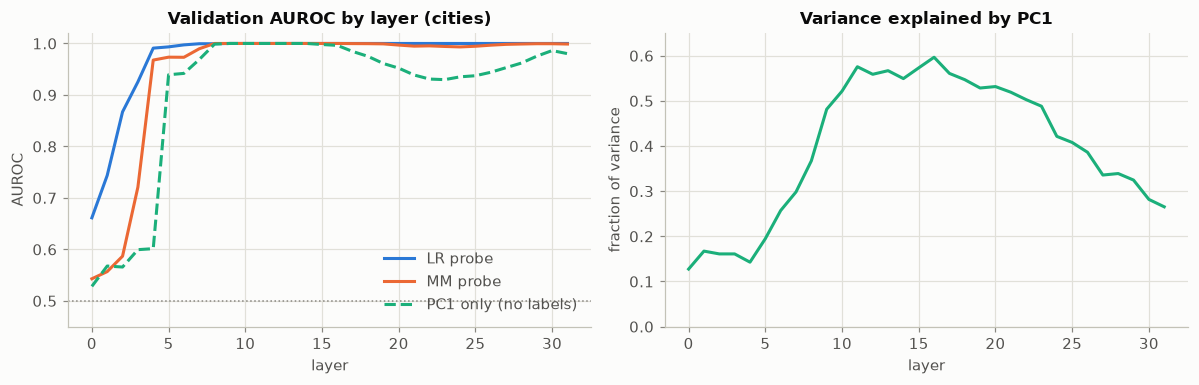

In [11]:
rows = []
for l in LAYERS:
    X = acts[l]
    mm = pl.fit_mass_mean(X[tr], y[tr])
    lr = pl.fit_logistic(X[tr], y[tr], C=0.1)
    pca = pl.fit_pca(X[tr], k=2)
    a_pc1 = pl.auroc(y[va], pca.transform(X[va])[:, 0])
    rows.append({
        "layer": l,
        "MM AUROC": pl.auroc(y[va], mm.score(X[va])),
        "LR AUROC": pl.auroc(y[va], lr.score(X[va])),
        "PC1 |AUROC|": max(a_pc1, 1 - a_pc1),
        "PC1 var": float(pca.explained[0]),
        "MM d'": pl.dprime(mm, X[va], y[va]),
        "MM acc": pl.accuracy(y[va], mm.score(X[va])),
    })
sweep = pd.DataFrame(rows).set_index("layer")
display(sweep.iloc[[0, 1, 2, 3, 4, 6, 8, 10, 12, 14, 16, 20, 24, 28, 31]])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
ax = axes[0]
ax.plot(sweep.index, sweep["LR AUROC"], color=pl.C_TRUE, label="LR probe")
ax.plot(sweep.index, sweep["MM AUROC"], color=pl.C_FALSE, label="MM probe")
ax.plot(sweep.index, sweep["PC1 |AUROC|"], color=pl.C_THIRD, ls="--", label="PC1 only (no labels)")
ax.axhline(0.5, color=pl.MUTED, lw=1, ls=":")
ax.set(title="Validation AUROC by layer (cities)", xlabel="layer", ylabel="AUROC", ylim=(0.45, 1.02))
ax.legend(loc="lower right")
ax = axes[1]
ax.plot(sweep.index, sweep["PC1 var"], color=pl.C_THIRD)
ax.set(title="Variance explained by PC1", xlabel="layer", ylabel="fraction of variance", ylim=(0, 0.65))
plt.tight_layout()
plt.show()

#### Cell 10 · PCA 그림: 분리가 생기기 전과 후

- **이번 셀의 질문:** layer 2와 layer 12에서 train으로 맞춘 PCA에 validation 문장을 투영하면 어떻게 보이는가?
- **출력에서 볼 것:** layer 2에서는 참(파랑)과 거짓(주황)이 섞여 있다. layer 12에서는 PC1 축을 따라 완전히 갈라지는데, **참 문장은 좁은 덩어리로 모이고 거짓 문장은 넓게 퍼진다.**
- **해석 범위:** PCA를 맞출 때는 label을 쓰지 않았다. 그러나 점을 label로 **색칠한** 순간 해석에는 감독 정보가 들어간다. 이 그림 하나로 '비지도 발견'을 주장하지 않는다. PC1이 마침 참/거짓과 겹친다는 사실이 왜 중요한지는 ②에서 다룬다.
- **다음 단계의 목적:** AUROC가 포화된 상태에서 probe 층을 미리 정한 규칙으로 고른다.

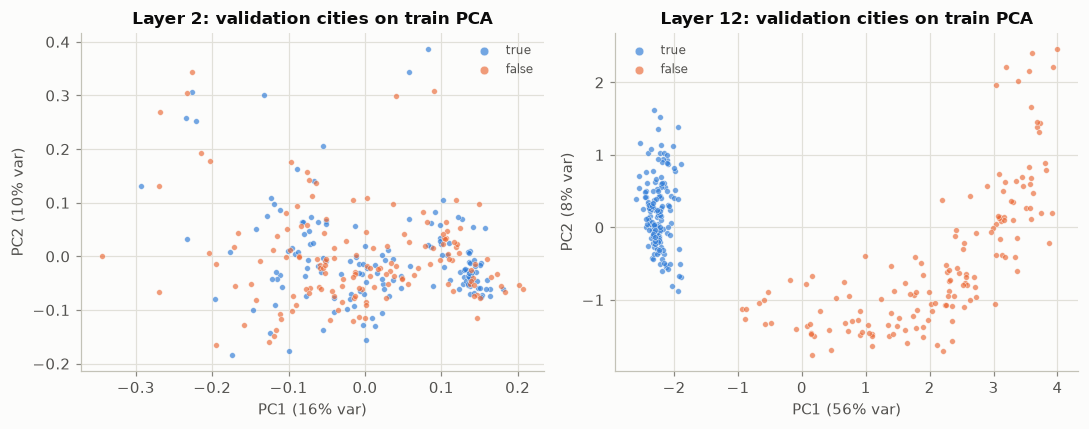

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, l in zip(axes, [2, 12]):
    pca = pl.fit_pca(acts[l][tr], k=2)
    Z = pca.transform(acts[l][va])
    pl.scatter_classes(ax, Z, y[va], title=f"Layer {l}: validation cities on train PCA",
                       xlabel=f"PC1 ({pca.explained[0]:.0%} var)", ylabel=f"PC2 ({pca.explained[1]:.0%} var)")
plt.tight_layout()
plt.show()

## probe 층을 고르는 규칙 (A2 선택 편향 차단)

validation AUROC가 layer 8 이후 전부 1.000이라 AUROC로는 층을 고를 수 없다. 이때 test 성능을 보고 고르면 **선택 편향**이 생긴다. 그래서 test를 열기 전에 규칙을 정한다.

> **규칙:** validation에서 MM probe의 분리도 $d'$ (두 class 평균 간격 ÷ class 내부 표준편차)가 최대인 층을 고른다.

$d'$은 AUROC가 포화된 뒤에도 "얼마나 여유 있게 분리되는가"를 비교할 수 있다. 이 층을 ②~⑧ 전체에서 **고정**한다.

#### Cell 11 · 규칙에 따른 probe 층 선택

- **이번 셀의 질문:** validation d′ 기준으로 어느 층이 선택되는가?
- **출력에서 볼 것:** 저장된 출력은 layer 12(d′≈5.35)다. layer 13(≈5.33)과 사실상 같다. Bürger et al.이 Llama-3-8B-Instruct에서 layer 12를 쓴 것과 우연히 일치한다.
- **해석 범위:** 12와 13의 차이는 의미 없는 수준이다. 중요한 것은 **test를 보기 전에** 규칙으로 고정했다는 절차다. ②에서 split seed 5개로 반복하면 모두 12가 뽑힌다.
- **다음 단계의 목적:** 고정한 층에서 test를 단 한 번 평가한다.

In [13]:
PROBE_LAYER = int(sweep["MM d'"].idxmax())
display(sweep["MM d'"].sort_values(ascending=False).head(4).to_frame())
print("PROBE_LAYER =", PROBE_LAYER)

,MM d'
layer,
12,5.355
13,5.334
14,4.893
15,4.257


PROBE_LAYER = 12


#### Cell 12 · 고정한 층에서 test 평가 (한 번만)

- **이번 셀의 질문:** 선택에 쓰지 않은 298문장(149개 도시)에서 두 probe의 성능은?
- **출력에서 볼 것:** 저장된 출력: MM AUROC 1.000 / accuracy 0.956, LR AUROC 1.000 / accuracy 1.000. 도시 단위 bootstrap 95% 구간은 [1.000, 1.000]으로 퇴화한다.
- **해석 범위:** MM의 accuracy가 AUROC보다 낮은 것은 순위는 완벽한데 **중점 threshold**가 최적이 아니기 때문이다. 앞 PCA 그림처럼 참은 좁게, 거짓은 넓게 퍼져 있으면 두 평균의 중점은 좁은 쪽(참)에 너무 가깝다. 구간이 [1,1]인 것은 '모집단 성능이 확실히 1'이라는 뜻이 아니다. test에서 완전 분리가 일어나면 percentile bootstrap이 퇴화할 뿐이다. 이 구간은 **고정된 probe의 평가 표본 변동**만 반영한다(재학습·층 선택의 불확실성은 미포함).
- **다음 단계의 목적:** 주장 장부의 첫 항목을 쓴다.

In [14]:
X = acts[PROBE_LAYER]
mm = pl.fit_mass_mean(X[tr], y[tr])
lr = pl.fit_logistic(X[tr], y[tr], C=0.1)
test_rows = []
for name, probe in [("MM", mm), ("LR", lr)]:
    s = probe.score(X[te])
    lo, hi = pl.group_bootstrap_ci(y[te], s, cities["group"].to_numpy()[te], n_boot=1000)
    test_rows.append({"probe": name, "test AUROC": pl.auroc(y[te], s), "test acc": pl.accuracy(y[te], s),
                      "95% CI (city bootstrap)": f"[{lo:.3f}, {hi:.3f}]"})
test_table = pd.DataFrame(test_rows)
display(test_table)
print("cos(MM, LR) at probe layer =", round(pl.cosine(mm.direction, lr.direction), 3))

,probe,test AUROC,test acc,95% CI (city bootstrap)
0,MM,1.0,0.956,"[1.000, 1.000]"
1,LR,1.0,1.000,"[1.000, 1.000]"


cos(MM, LR) at probe layer = 0.491


### 여기까지의 결론

- 참/거짓은 layer 4 무렵부터 선형으로 읽히기 시작하고, layer 8 이후에는 validation에서 사실상 완전히 분리된다.
- layer 9–14에서는 **label 없이 구한 PC1 하나**가 분산의 절반 이상을 설명하면서 참/거짓을 완전히 가른다. 이 데이터에서 참/거짓은 activation이 변하는 **가장 큰 축**이다.
- 미리 정한 규칙으로 layer 12를 골랐고, 처음 보는 149개 도시에서 test AUROC 1.000을 얻었다.
- 같은 층에서도 MM 방향과 LR 방향은 cosine 0.49로 꽤 다르다. 두 probe가 같은 성능을 내도 **같은 방향을 찾은 것은 아니다.** 어느 방향이 "모델의 변수"에 가까운지는 ④에서 개입으로 묻는다.

## 주장 장부 — ①의 갱신

| ID | 주장 | 근거 | 아직 배제하지 못한 설명 | 상태 |
|---|---|---|---|---|
| C1 | Llama-3.1-8B-Instruct의 layer 12 residual(문장 끝 마침표)에서, 학습에 쓰지 않은 도시들의 `The city of X is in Y.` 문장의 참/거짓이 선형으로 거의 완전히 분리된다. | ① 층 sweep(validation), 규칙으로 고정한 층, test AUROC 1.000 (MM·LR), 도시 단위 split | A3 표면 통계, A4 probe 용량, A5 확률, A6 데이터셋 특수성, A7 부수현상 | **관찰됨** |

**아직 말할 수 없는 것:** 이 방향이 "진실"이라는 것(A5, A6), 모델이 그것을 쓴다는 것(A7), 다른 데이터에서도 통한다는 것(A6). ②가 A3·A4·A5를 맡는다.

#### Cell 13 · 결과 저장

- **이번 셀의 질문:** ⑤와 ⑧이 모아 읽을 핵심 수치를 기록한다.
- **출력에서 볼 것:** `results/01_observation.json` 경로가 출력된다.
- **해석 범위:** 숫자만 저장한다. 그림과 해석은 notebook에 남는다.
- **다음 단계의 목적:** ② 성공을 증거로 만들기 — 대안 설명 A3·A4·A5를 실험으로 약화시킨다.

In [15]:
pl.save_results("01_observation", {
    "model": pl.DEFAULT_MODEL,
    "probe_layer": PROBE_LAYER,
    "split_rows": {"train": len(tr), "val": len(va), "test": len(te)},
    "sweep": sweep.reset_index().to_dict(orient="records"),
    "test": test_table.to_dict(orient="records"),
    "cos_mm_lr": pl.cosine(mm.direction, lr.direction),
    "claims": [{"id": "C1", "status": "관찰됨",
                "text": "L12 마침표 위치에서 cities 문장의 참/거짓이 선형으로 거의 완전히 분리된다 (test AUROC 1.000)."}],
})

PosixPath('/workspace/ARENA_3.0/chapter1_transformer_interp/exercises/part31_linear_probes_ko/results/01_observation.json')